# **Part II: applying the lab techniques to the project\\**

# OPSSAT-AD: Satellite Telemetry Anomaly Detection

For this project we initially considered three different public datasets related to security and anomalies:

- a network intrusion dataset (CIC-IDS 2017),
- the TON_IoT collection (IoT / IIoT telemetry and network data),
- the OPSSAT-AD dataset, built from a CubeSat mission operated by the European Space Agency.

The first two datasets are mainly focused on general network traffic and IoT devices (fridge, thermostat, GPS tracker, etc.). They are very useful for intrusion detection, but they only capture the “ground” side of the problem. Since our project specifically targets cyberattacks and anomalies on satellites and space infrastructure, we decided to focus on **OPSSAT-AD**, which is directly based on real satellite telemetry.

OPSSAT-AD provides preprocessed segments of telemetry signals. Each sample corresponds to a segment of a telemetry channel and comes with:
- a set of handcrafted features (mean, variance, standard deviation, kurtosis, skewness, number of peaks, differences of variance, etc.),
- metadata such as segment length, duration and sampling rate,
- a binary label `anomaly` (0 = nominal, 1 = anomalous),
- a `train` flag indicating whether the segment belongs to the training or test split defined by the authors.

In other words, the dataset is already in a tabular format designed for machine learning experiments. In a real industrial setting, a data engineer would start from raw telemetry streams and build this kind of feature table. Here we adopt the point of view of a data scientist working in a research context: we assume that the feature extraction pipeline has already been done, and we concentrate on model selection, hyperparameter tuning and ensemble methods.

In this notebook we will:

- load and briefly explore the OPSSAT-AD tabular dataset (`dataset.csv`),
- use the predefined `train` split to separate training and test data,
- build baseline classifiers (Decision Tree and SVM),
- tune their hyperparameters with `GridSearchCV`,
- apply ensemble techniques (Bagging and a hybrid VotingClassifier),
- evaluate and compare the models using accuracy, precision, recall, F1-score and confusion matrices,
- discuss which approach offers the best trade-off between detection performance and operational usefulness for satellite telemetry monitoring.


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, VotingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [ ]:
# Data size
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (2123, 23)


,segment,anomaly,train,channel,sampling,duration,len,mean,var,std,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,1,1,1,CADC0872,1,279,280,8.533143e-07,3.494283e-10,0.000019,...,3,2,4,6,1.271176e-10,2.960666e-10,279,280,1.252431e-12,1.247958e-12
1,2,1,1,CADC0872,1,476,477,-3.639396e-06,6.476485e-10,0.000025,...,1,1,5,8,1.489383e-12,3.004752e-12,476,477,1.360606e-12,1.357754e-12
2,3,1,1,CADC0872,1,594,595,1.170788e-05,5.592877e-10,0.000024,...,2,2,2,3,4.112280e-12,1.029918e-11,594,595,9.415618e-13,9.399794e-13
3,4,1,1,CADC0872,1,271,272,8.486808e-07,5.466024e-10,0.000023,...,2,2,3,6,2.475760e-11,6.240985e-11,271,272,2.016983e-12,2.009568e-12
4,5,0,0,CADC0872,1,256,257,1.058485e-05,5.279023e-10,0.000023,...,1,1,78,87,5.547101e-13,7.035422e-13,256,257,2.062118e-12,2.054094e-12


## Dataset description

The OPSSAT-AD tabular dataset (`dataset.csv`) contains precomputed features extracted from telemetry segments of the ESA OPSSAT CubeSat. Each row corresponds to one segment of a telemetry channel, and the columns describe statistical and structural properties of the signal over that segment.

In our copy of the dataset we have:

- **2123 segments** in total
- **23 columns**, including:
  - identifiers and metadata: `segment`, `channel`, `sampling`, `duration`, `len`
  - statistical features: `mean`, `var`, `std`, `kurtosis`, `skew`
  - shape / peak features: `n_peaks`, `smooth10_n_peaks`, `smooth20_n_peaks`, `diff_peaks`, `diff2_peaks`
  - variance- and gap-related features: `diff_var`, `diff2_var`, `gaps_squared`, `len_weighted`, `var_div_duration`, `var_div_len`
  - supervision and split information: `anomaly`, `train`

The target variable is:

- **`anomaly`**  
  - `0` = nominal segment  
  - `1` = anomalous segment  

The proportion of anomalies is around one fifth of the dataset, which makes this a slightly imbalanced but still workable binary classification problem.

The column **`train`** is a binary flag provided by the dataset authors:

- `train = 1` → sample belongs to the training set  
- `train = 0` → sample belongs to the test set  

In our case this leads to:

- **1594 training samples**
- **529 test samples**

We use this predefined split instead of drawing a new one with `train_test_split`, so that our experiments remain comparable to the original OPSSAT-AD benchmark and we do not “leak” information from the test set into training. The only preprocessing we apply is:

- standardising numerical features,
- one-hot encoding the categorical feature `channel`.

No heavy cleaning or feature engineering is performed here, because the goal of this lab is to study model selection, hyperparameter tuning and ensemble methods on a satellite telemetry problem, not to redesign the whole signal-processing pipeline behind OPSSAT-AD.

In [ ]:
# Target variable
y = df["anomaly"]

# Features: drop ID and the 'train' flag from the input features
X = df.drop(columns=["anomaly", "segment"])

# Predefined train/test split from the dataset
train_mask = df["train"] == 1
test_mask = df["train"] == 0

X_train = X[train_mask].copy()
X_test = X[test_mask].copy()
y_train = y[train_mask].copy()
y_test = y[test_mask].copy()

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (1594, 21)  Test size: (529, 21)


In [ ]:
# Identify categorical and numerical columns
categorical_features = ["channel"]
numeric_features = [col for col in X.columns if col not in ["channel"]]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [ ]:
# Baseline models
dt = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)

# Pipelines: preprocessing + model
dt_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", dt)
])

svm_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", svm)
])

# Hyperparameter grids
param_grid_dt = {
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

param_grid_svm = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"],
}

In [ ]:
dt_grid = GridSearchCV(
    estimator=dt_pipe,
    param_grid=param_grid_dt,
    cv=3,
    scoring="f1",  # f1 is relevant because anomalies are the positive class
    n_jobs=-1,
    verbose=1
)

svm_grid = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid_svm,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)
svm_grid.fit(X_train, y_train)

print("Best params (Decision Tree):", dt_grid.best_params_)
print("Best CV F1 (Decision Tree):", dt_grid.best_score_)

print("Best params (SVM):", svm_grid.best_params_)
print("Best CV F1 (SVM):", svm_grid.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params (Decision Tree): {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV F1 (Decision Tree): 0.7625271258130283
Best params (SVM): {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best CV F1 (SVM): 0.7085175621570344


In [ ]:
from time import perf_counter

results = {}

def evaluate_model(name, model, X_test, y_test):
    start = perf_counter()
    y_pred = model.predict(X_test)
    end = perf_counter()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    infer_time = end - start

    results[name] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "inference_time": infer_time,
        "y_pred": y_pred
    }

    print(f"{name} – Accuracy: {acc:.4f}")
    print(f"{name} – Precision: {prec:.4f}")
    print(f"{name} – Recall: {rec:.4f}")
    print(f"{name} – F1-score: {f1:.4f}")
    print(f"{name} – Inference time (s): {infer_time:.6f}")
    print("-" * 50)

best_dt = dt_grid.best_estimator_
best_svm = svm_grid.best_estimator_

evaluate_model("Decision Tree (tuned)", best_dt, X_test, y_test)
evaluate_model("SVM (tuned)", best_svm, X_test, y_test)

Decision Tree (tuned) – Accuracy: 0.9433
Decision Tree (tuned) – Precision: 0.9882
Decision Tree (tuned) – Recall: 0.7434
Decision Tree (tuned) – F1-score: 0.8485
Decision Tree (tuned) – Inference time (s): 0.009724
--------------------------------------------------
SVM (tuned) – Accuracy: 0.9452
SVM (tuned) – Precision: 0.9773
SVM (tuned) – Recall: 0.7611
SVM (tuned) – F1-score: 0.8557
SVM (tuned) – Inference time (s): 0.019828
--------------------------------------------------


In [ ]:
# Bagging on top of the best tuned models

# 1) Extract the tuned base models from the GridSearch pipelines
#    (we only keep the "model" step, not the whole pipeline)
best_dt_model = dt_grid.best_estimator_.named_steps["model"]
best_svm_model = svm_grid.best_estimator_.named_steps["model"]

# 2) Build new pipelines: preprocessing + Bagging(DecisionTree / SVM)
bag_dt = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", BaggingClassifier(
        estimator=best_dt_model,
        n_estimators=10,
        max_samples=0.8,
        n_jobs=-1,
        random_state=42
    ))
])

bag_svm = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", BaggingClassifier(
        estimator=best_svm_model,
        n_estimators=10,
        max_samples=0.8,
        n_jobs=-1,
        random_state=42
    ))
])

# 3) Fit the bagging ensembles on the training data
bag_dt.fit(X_train, y_train)
bag_svm.fit(X_train, y_train)

# 4) Evaluate the bagging models on the test set
evaluate_model("Bagging Decision Tree", bag_dt, X_test, y_test)
evaluate_model("Bagging SVM", bag_svm, X_test, y_test)

# Hybrid Voting ensemble using the two bagged models
voting = VotingClassifier(
    estimators=[
        ("bag_svm", bag_svm),
        ("bag_dt", bag_dt)
    ],
    voting="soft"  # average predicted probabilities
)

# 5) Fit the voting classifier and evaluate it
voting.fit(X_train, y_train)
evaluate_model("Voting (Bagging SVM + Bagging DT)", voting, X_test, y_test)

Bagging Decision Tree – Accuracy: 0.9433
Bagging Decision Tree – Precision: 0.9882
Bagging Decision Tree – Recall: 0.7434
Bagging Decision Tree – F1-score: 0.8485
Bagging Decision Tree – Inference time (s): 0.017042
--------------------------------------------------
Bagging SVM – Accuracy: 0.9433
Bagging SVM – Precision: 0.9560
Bagging SVM – Recall: 0.7699
Bagging SVM – F1-score: 0.8529
Bagging SVM – Inference time (s): 0.059705
--------------------------------------------------
Voting (Bagging SVM + Bagging DT) – Accuracy: 0.9490
Voting (Bagging SVM + Bagging DT) – Precision: 0.9778
Voting (Bagging SVM + Bagging DT) – Recall: 0.7788
Voting (Bagging SVM + Bagging DT) – F1-score: 0.8670
Voting (Bagging SVM + Bagging DT) – Inference time (s): 0.088226
--------------------------------------------------


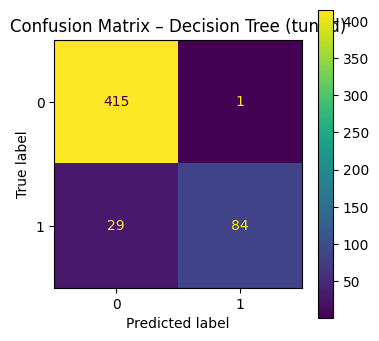

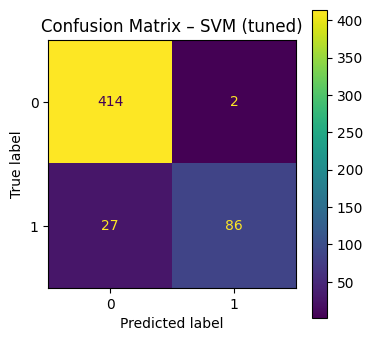

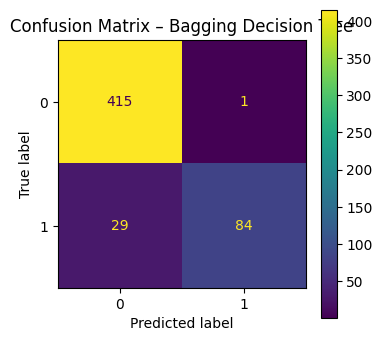

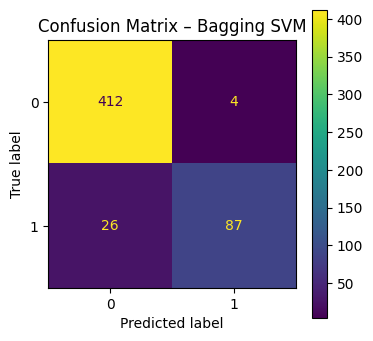

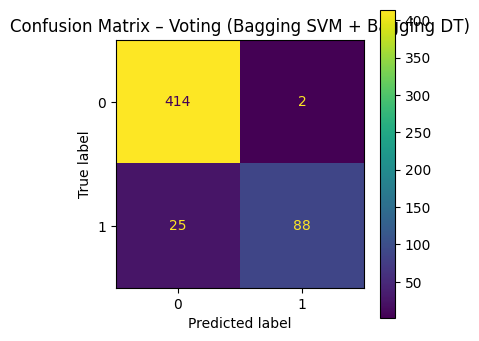

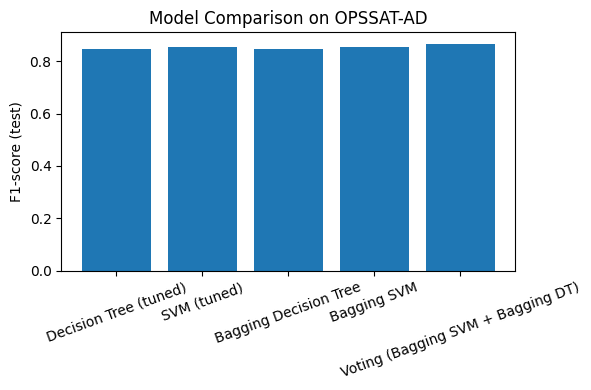

In [ ]:
# Confusion matrices
for name, res in results.items():
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax)
    ax.set_title(f"Confusion Matrix – {name}")
    plt.show()

# Bar chart of F1-scores
model_names = list(results.keys())
f1_scores = [results[m]["f1"] for m in model_names]

plt.figure(figsize=(6, 4))
plt.bar(model_names, f1_scores)
plt.ylabel("F1-score (test)")
plt.xticks(rotation=20)
plt.title("Model Comparison on OPSSAT-AD")
plt.tight_layout()
plt.show()

### Evaluation on the OPSSAT-AD dataset

All models achieve strong performance on the satellite telemetry anomaly detection task, but there are some clear differences.

The tuned Decision Tree reaches an accuracy of about 94% with a very high precision (almost no false positives), but its recall is more limited: it misses around 29 anomalous segments on the test set. This means that the tree is conservative and tends to classify borderline cases as normal.

The tuned SVM slightly improves the F1-score compared to the tree. It still keeps the number of false positives low, but recovers a few more anomalies (higher recall). This is consistent with the idea that SVMs can model more complex decision boundaries in the feature space.

Bagging has very little effect on the Decision Tree in this dataset: the confusion matrix and the F1-score are almost unchanged, suggesting that the single tuned tree is already relatively stable. For the SVM, bagging gives a small boost in recall (fewer missed anomalies) at the cost of a few more false positives.

The hybrid VotingClassifier, which combines the bagged SVM and the bagged Decision Tree with soft voting, provides the best overall trade-off. It achieves the highest F1-score, with the lowest number of missed anomalies (false negatives) while keeping the number of false alarms (false positives) very small.

From a satellite operations point of view, this trade-off is important: missing anomalies can be risky for the health of the spacecraft, whereas a small number of additional false alarms is usually acceptable. In that sense, the voting ensemble is the most attractive option for monitoring OPSSAT telemetry, while the tuned SVM alone remains a strong and simpler baseline.

## Conclusion – Part II: applying the lab techniques to the project

In the first part of the lab we experimented with relatively simple datasets (Breast Cancer, SVM vs Decision Tree, Bagging and Voting) in order to understand how hyperparameter tuning and ensemble methods affect performance. In this second part, we applied exactly the same ideas to a more realistic scenario: anomaly detection in satellite telemetry from the OPSSAT mission.

Among several candidate datasets (network intrusion data, IoT/IIoT traffic and satellite telemetry), we deliberately chose OPSSAT-AD because it is directly related to space systems and already provides a clean, tabular representation of telemetry segments. This allowed us to work in a data scientist mindset: rather than spending most of the time on raw log parsing and feature extraction, we assumed that the engineering pipeline was already in place and focused on model selection, GridSearchCV and ensembles.

Using the predefined train/test split and the anomaly labels, we built and tuned Decision Tree and SVM baselines, then extended them with Bagging and a hybrid VotingClassifier. The experiments show that:
- SVM models provide slightly better F1-scores than a single Decision Tree;
- Bagging is mainly helpful for the SVM, by improving recall at the cost of a few extra false alarms;
- the Voting ensemble achieves the best global trade-off between accuracy, recall and robustness.

Overall, this part of the project demonstrates how the techniques introduced in the lab (hyperparameter search, bagging, voting) can be transferred from toy datasets to a realistic satellite telemetry problem. The same workflow could later be reused on other sources such as TON_IoT or network intrusion datasets, or extended with more advanced ensembles and anomaly detection methods.
